# Fusion Trust Classifier — Complete Technical Document

This notebook documents the fusion trust classifier used in the dual-modality drone detection system. It covers:
- Architecture & trust classes
- All 40 features (7 categories)
- Dataset construction (152K paired RGB+IR frames)
- Training configuration & metrics
- Full evaluation of 10 fusion approaches
- Feature importance analysis
- Deployment integration


In [12]:
import json
import os
import joblib
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from IPython.display import display, Image, Markdown
from pathlib import Path

# Paths
CLASSIFIER_DIR = Path(r"c:\Users\User\Desktop\UNISA projects\Drone detection\es proj 3 thesis workspace\ES_Drone_Detection\classifier")
FUSION_DIR = CLASSIFIER_DIR / "runs" / "reliability" / "fusion"

print("Paths configured.")
print(f"  Classifier: {CLASSIFIER_DIR}")
print(f"  Fusion data: {FUSION_DIR}")


Paths configured.
  Classifier: c:\Users\User\Desktop\UNISA projects\Drone detection\es proj 3 thesis workspace\ES_Drone_Detection\classifier
  Fusion data: c:\Users\User\Desktop\UNISA projects\Drone detection\es proj 3 thesis workspace\ES_Drone_Detection\classifier\runs\reliability\fusion


## 1. Overview

The fusion trust classifier is a **frame-level XGBoost model** that decides which modality to trust for each paired RGB+IR frame. Rather than naively combining detections (which amplifies false positives), the classifier examines each frame's detection signals, scene conditions, and target characteristics to make a **4-class trust decision**.

### Trust Classes

| Label | Name | Meaning |
|:---:|---|---|
| **0** | `reject_both` | Neither modality produced a valid detection — suppress all |
| **1** | `trust_rgb` | Only the RGB model is reliable — suppress IR detections |
| **2** | `trust_ir` | Only the IR model is reliable — suppress RGB detections |
| **3** | `trust_both` | Both modalities correct — accept all detections |

### Model
- **Algorithm**: XGBoost (`XGBClassifier`, `multi:softprob`, 4-class)
- **Output**: Class label + probability vector `[P(reject), P(rgb), P(ir), P(both)]`
- **Serialization**: `joblib` bundle `{"model": ..., "features": [...]}`


In [13]:
# Load the deployed model
model_path = FUSION_DIR / "fusion_no_fn_model.joblib"
if model_path.exists():
    bundle = joblib.load(model_path)
    model = bundle["model"]
    feature_names = bundle["features"]
    print(f"Model loaded: {len(feature_names)} features")
    print(f"Model type: {type(model).__name__}")
    print(f"\nFeature list:")
    for i, f in enumerate(feature_names):
        print(f"  {i+1:2d}. {f}")
else:
    print(f"Model not found at {model_path}")
    feature_names = []


Model loaded: 40 features
Model type: XGBClassifier

Feature list:
   1. rgb_n_dets
   2. rgb_max_conf
   3. rgb_mean_conf
   4. rgb_detected
   5. ir_n_dets
   6. ir_max_conf
   7. ir_mean_conf
   8. ir_detected
   9. rgb_img_mean
  10. rgb_img_std
  11. rgb_img_dynamic_range
  12. rgb_img_entropy
  13. rgb_sky_ground_ratio
  14. rgb_edge_density
  15. rgb_blurriness
  16. ir_img_mean
  17. ir_img_std
  18. ir_img_dynamic_range
  19. ir_img_entropy
  20. ir_sky_ground_ratio
  21. ir_edge_density
  22. ir_blurriness
  23. rgb_best_log_bbox_area
  24. rgb_best_aspect_ratio
  25. rgb_best_pos_x
  26. rgb_best_pos_y
  27. rgb_best_dist_to_center
  28. rgb_best_local_contrast
  29. rgb_best_target_bg_delta
  30. ir_best_log_bbox_area
  31. ir_best_aspect_ratio
  32. ir_best_pos_x
  33. ir_best_pos_y
  34. ir_best_dist_to_center
  35. ir_best_local_contrast
  36. ir_best_target_bg_delta
  37. both_detect
  38. neither_detect
  39. rgb_only_detect
  40. ir_only_detect


## 2. Feature Architecture (40 Features)

All 40 features are computable at inference time from raw frames and YOLO outputs. No pre-trained failure-mode models required.

### 2.1 Detection Aggregates (14 features — 7 per modality)

| Feature | Description |
|---|---|
| `rgb_n_dets` / `ir_n_dets` | Number of detections per modality |
| `rgb_max_conf` / `ir_max_conf` | Highest confidence score |
| `rgb_mean_conf` / `ir_mean_conf` | Mean confidence across all detections |
| `rgb_detected` / `ir_detected` | Binary flag: 1 if ≥1 detection, else 0 |

> Confidence scores come from YOLO inference at `conf=0.001` — the classifier, not YOLO's threshold, makes the acceptance decision.

### 2.2 Scene-Level Features (14 features — 7 per modality)

| Feature | Description | Rationale |
|---|---|---|
| `img_mean` | Mean pixel intensity | Exposure level; night vs day |
| `img_std` | Pixel standard deviation | Scene contrast |
| `img_dynamic_range` | P98 − P2 percentile range | Useful range of intensities |
| `img_entropy` | Shannon entropy of histogram | Scene complexity |
| `sky_ground_ratio` | top_half_mean / bottom_half_mean | Skyline indicator |
| `edge_density` | Fraction of Canny edge pixels | Texture density |
| `blurriness` | Laplacian variance | Focus quality / motion blur |

### 2.3 Best-Detection Target Features (14 features — 7 per modality)

| Feature | Description | Rationale |
|---|---|---|
| `best_log_bbox_area` | log(bbox_area + 1) | Size of putative target |
| `best_aspect_ratio` | width / height | Shape characteristic |
| `best_pos_x` / `best_pos_y` | Normalized center position (0–1) | Spatial location |
| `best_dist_to_center` | Euclidean distance to image center | Vignetting / lens effects |
| `best_local_contrast` | (target_mean − bg_mean) / bg_std | Target saliency |
| `best_target_bg_delta` | target_mean − bg_mean (raw) | Absolute brightness difference |

### 2.4 Frame-Level Agreement Flags (4 features)

| Feature | Condition |
|---|---|
| `both_detect` | RGB ≥1 AND IR ≥1 |
| `neither_detect` | RGB = 0 AND IR = 0 |
| `rgb_only_detect` | RGB ≥1 AND IR = 0 |
| `ir_only_detect` | RGB = 0 AND IR ≥1 |

These are mutually exclusive one-hot flags.


## 3. Training Dataset

In [14]:
# Load the fusion dataset
csv_path = FUSION_DIR / "fusion_dataset.csv"
if csv_path.exists():
    df = pd.read_csv(csv_path)
    print(f"Dataset: {len(df):,} paired RGB+IR frames")
    print(f"\n=== Source Datasets ===")
    print(df["source_dataset"].value_counts().to_string())
    print(f"\n=== Class Distribution ===")
    label_names = {0: "reject_both", 1: "trust_rgb", 2: "trust_ir", 3: "trust_both"}
    for val in sorted(df["trust_label"].unique()):
        n = (df["trust_label"] == val).sum()
        pct = n / len(df) * 100
        print(f"  {val} ({label_names[val]:12s}): {n:>7,} ({pct:.1f}%)")
    print(f"\n=== Drone Presence ===")
    drone_present = df["drone_present"].value_counts()
    print(f"  Drone present:  {drone_present.get(1, 0):>7,} ({drone_present.get(1, 0)/len(df)*100:.1f}%)")
    print(f"  No drone:       {drone_present.get(0, 0):>7,} ({drone_present.get(0, 0)/len(df)*100:.1f}%)")
    
    # TN breakdown
    reject_frames = df[df["trust_label"] == 0]
    no_drone_reject = reject_frames[reject_frames["drone_present"] == 0]
    both_miss = reject_frames[reject_frames["drone_present"] == 1]
    print(f"\n=== True Negative (reject_both) Composition ===")
    print(f"  No-drone background frames: {len(no_drone_reject):,}")
    print(f"  Both-miss frames (drone present, both missed): {len(both_miss):,}")
    print(f"  Total reject_both: {len(reject_frames):,}")
else:
    print(f"Dataset not found at {csv_path}")
    df = None


Dataset: 152,051 paired RGB+IR frames

=== Source Datasets ===
source_dataset
antiuav_test    85374
antiuav_val     37967
svanstrom       28710

=== Class Distribution ===
  0 (reject_both ):  19,815 (13.0%)
  1 (trust_rgb   ):   5,617 (3.7%)
  2 (trust_ir    ):  11,104 (7.3%)
  3 (trust_both  ): 115,515 (76.0%)

=== Drone Presence ===
  Drone present:  133,179 (87.6%)
  No drone:        18,872 (12.4%)

=== True Negative (reject_both) Composition ===
  No-drone background frames: 18,872
  Both-miss frames (drone present, both missed): 943
  Total reject_both: 19,815


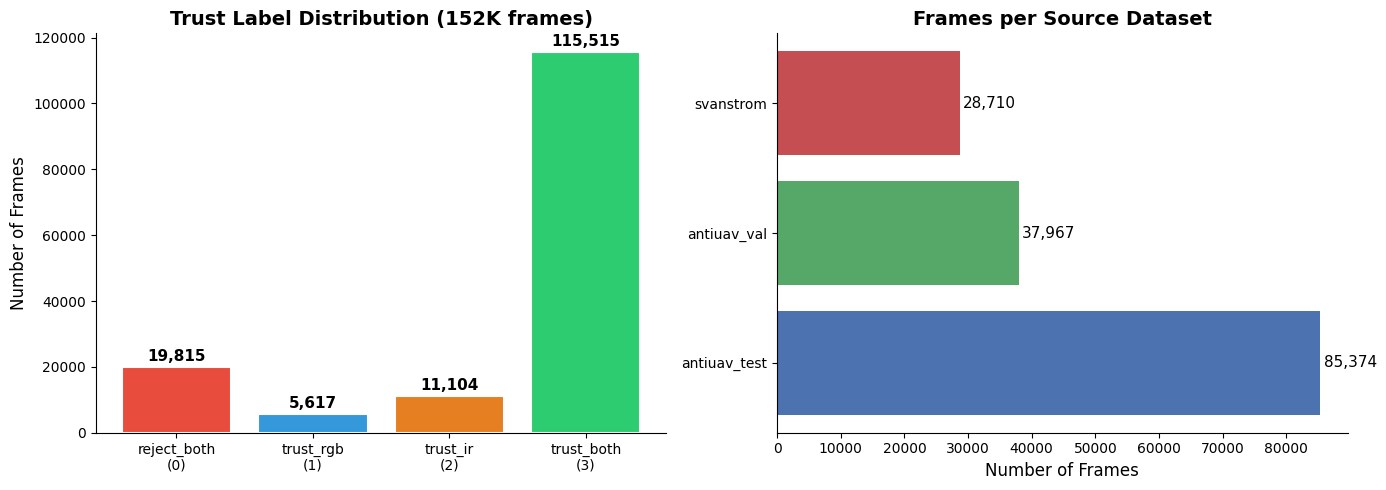

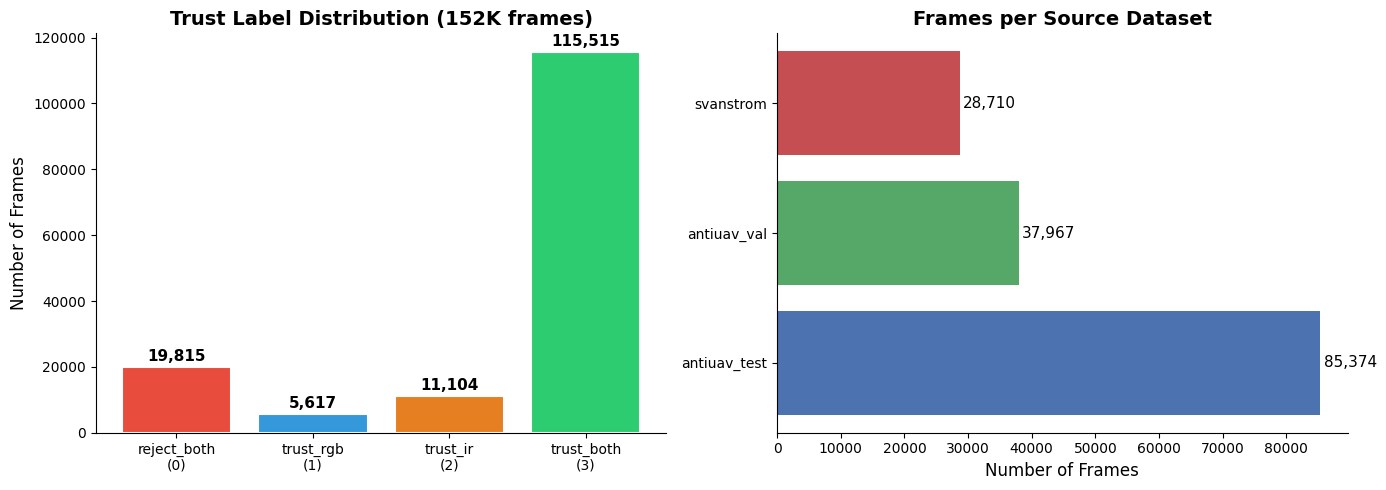

In [15]:
if df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Class distribution
    ax = axes[0]
    labels = ["reject_both\n(0)", "trust_rgb\n(1)", "trust_ir\n(2)", "trust_both\n(3)"]
    counts = [df[df["trust_label"] == i].shape[0] for i in range(4)]
    colors = ["#e74c3c", "#3498db", "#e67e22", "#2ecc71"]
    bars = ax.bar(labels, counts, color=colors, edgecolor="white", linewidth=1.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                f"{count:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylabel("Number of Frames", fontsize=12)
    ax.set_title("Trust Label Distribution (152K frames)", fontsize=14, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Source dataset
    ax = axes[1]
    src_counts = df["source_dataset"].value_counts()
    ax.barh(src_counts.index, src_counts.values, color=["#4C72B0", "#55A868", "#C44E52"])
    for i, (idx, val) in enumerate(src_counts.items()):
        ax.text(val + 500, i, f"{val:,}", va="center", fontsize=11)
    ax.set_xlabel("Number of Frames", fontsize=12)
    ax.set_title("Frames per Source Dataset", fontsize=14, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    plt.tight_layout()
    plt.show()


### Labeling Methodology

Each frame is labeled by independently matching each modality's detections to its **own** GT annotations (no cross-modal spatial matching — RGB and IR are not co-registered):

```python
rgb_tp, rgb_fp, _ = match_dets_to_gt(rgb_dets, rgb_gt, iou_thresh=0.5)
ir_tp,  ir_fp, _  = match_dets_to_gt(ir_dets,  ir_gt,  iou_thresh=0.5)

if rgb_has_tp and ir_has_tp:     trust = 3  # trust_both
elif rgb_has_tp:                  trust = 1  # trust_rgb
elif ir_has_tp:                   trust = 2  # trust_ir
else:                             trust = 0  # reject_both
```

**Data split**: Sequence-level `GroupShuffleSplit` (70/30 train/test). All frames from the same video sequence stay together — no temporal leakage.


## 4. Model Configuration

| Parameter | Value |
|---|---|
| `n_estimators` | 400 |
| `max_depth` | 6 |
| `learning_rate` | 0.05 |
| `subsample` | 0.8 |
| `colsample_bytree` | 0.8 |
| `objective` | `multi:softprob` |
| `num_class` | 4 |
| `eval_metric` | `mlogloss` |
| `tree_method` | `hist` |


### Metric Definitions

**F1 Macro**: Compute F1 for each class independently, then take the unweighted average. Each class counts equally regardless of size — if `trust_rgb` (3.7% of data) performs poorly, it drags the score down just as much as `trust_both` (75%). This is the stricter metric.

**F1 Weighted**: Same per-class F1 scores, but averaged proportional to each class's sample count. Dominated by the majority class (`trust_both`), so it can look high (98.6%) even if rare classes are poorly predicted.

**Per-Class AUC(Area Under the ROC Curve) (One-vs-Rest)**: For each class, treat it as a binary problem — "is this frame class X, yes or no?" — and compute the AUC-ROC of the model's predicted probability for that class. An AUC of 0.9998 for `reject_both` means the model's P(reject) score almost perfectly separates reject frames from all others. Evaluated independently for each of the 4 classes.

AUC = 1.0: Perfect — the model's scores perfectly separate positives from negatives at some threshold
AUC = 0.5: Random — no better than coin flip
AUC = 0.9998: The model's predicted probability almost never ranks a negative sample higher than a positive one


## 5. Test Set Metrics

In [16]:
metrics_path = FUSION_DIR / "fusion_no_fn_metrics.json"
if metrics_path.exists():
    with open(metrics_path) as f:
        metrics = json.load(f)
    
    print("=" * 60)
    print("OVERALL PERFORMANCE")
    print("=" * 60)
    print(f"  Accuracy:      {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"  F1 (macro):    {metrics['f1_macro']:.4f} ({metrics['f1_macro']*100:.2f}%)")
    print(f"  F1 (weighted): {metrics['f1_weighted']:.4f} ({metrics['f1_weighted']*100:.2f}%)")
    print(f"  Train: {metrics['n_train']:,}  Test: {metrics['n_test']:,}")
    
    print(f"\n{'=' * 60}")
    print("PER-CLASS AUC (One-vs-Rest)")
    print("=" * 60)
    for cls, auc in metrics["per_class_auc"].items():
        print(f"  {cls:15s}: {auc:.4f}")
    
    print(f"\n{'=' * 60}")
    print("PER-DATASET BREAKDOWN")
    print("=" * 60)
    print(f"  {'Dataset':<16s} {'N':>7s} {'Acc':>7s} {'F1m':>7s} {'F1w':>7s}")
    for ds, res in metrics["per_dataset"].items():
        print(f"  {ds:<16s} {res['n']:>7,} {res['acc']:>7.4f} {res['f1_macro']:>7.4f} {res['f1_weighted']:>7.4f}")
else:
    print(f"Metrics not found at {metrics_path}")
    metrics = None


OVERALL PERFORMANCE
  Accuracy:      0.9867 (98.67%)
  F1 (macro):    0.9669 (96.69%)
  F1 (weighted): 0.9865 (98.65%)
  Train: 106,963  Test: 45,088

PER-CLASS AUC (One-vs-Rest)
  reject_both    : 0.9998
  trust_rgb      : 0.9922
  trust_ir       : 0.9976
  trust_both     : 0.9966

PER-DATASET BREAKDOWN
  Dataset                N     Acc     F1m     F1w
  antiuav_test      28,463  0.9900  0.9686  0.9898
  antiuav_val       10,319  0.9795  0.9323  0.9787
  svanstrom          6,306  0.9837  0.8633  0.9834


## 6. Baseline Comparisons

These are trivial "no-ML" heuristic policies measuring **4-class trust accuracy** (which modality to believe), not binary detection.

> ⚠️ **Why "Always trust IR" = 17% accuracy despite IR having 95%+ detection precision:**
> This policy predicts `trust_ir` (class 2) whenever IR detects, but **never predicts `trust_both` (class 3)**. Since 76% of GT frames are `trust_both`, it misclassifies them all → only 17% accuracy. IR is an excellent detector, but a policy that always credits IR alone ignores the frames where both modalities are correct.


In [24]:
if metrics is not None:
    print("=" * 65)
    print("BASELINE COMPARISON (4-class trust accuracy)")
    print("=" * 65)
    print(f"  {'Policy':<25s} {'Accuracy':>9s} {'F1 macro':>9s} {'F1 weighted':>11s}")
    print(f"  {'-'*25} {'-'*9} {'-'*9} {'-'*11}")
    
    # All heuristic baselines collapse to the same rule
    b = metrics["baselines"]["higher_conf"]
    print(f"  {'Naive agreement rule':<25s} {b['accuracy']:>9.4f} {b['f1_macro']:>9.4f} {b['f1_weighted']:>11.4f}")
    print(f"  {'-'*25} {'-'*9} {'-'*9} {'-'*11}")
    print(f"  {'XGBoost (#10)':<25s} {metrics['accuracy']:>9.4f} {metrics['f1_macro']:>9.4f} {metrics['f1_weighted']:>11.4f}")
    
    print(f"\n  Improvement over naive rule:")
    print(f"    Accuracy: +{(metrics['accuracy'] - b['accuracy'])*100:.1f}%")
    print(f"    F1 macro: +{(metrics['f1_macro'] - b['f1_macro'])*100:.1f}%")
    print(f"\n  The naive rule = 'trust whoever detected'. All heuristic")
    print(f"  baselines collapse to this because 'both detect' → trust_both")
    print(f"  covers 76% of frames, leaving no room for confidence or")
    print(f"  modality preference to matter.")


BASELINE COMPARISON (4-class trust accuracy)
  Policy                     Accuracy  F1 macro F1 weighted
  ------------------------- --------- --------- -----------
  Naive agreement rule         0.9273    0.7790      0.9313
  ------------------------- --------- --------- -----------
  XGBoost (#10)                0.9867    0.9669      0.9865

  Improvement over naive rule:
    Accuracy: +5.9%
    F1 macro: +18.8%

  The naive rule = 'trust whoever detected'. All heuristic
  baselines collapse to this because 'both detect' → trust_both
  covers 76% of frames, leaving no room for confidence or
  modality preference to matter.


The classifier's +5.9% accuracy gain is entirely on the edge cases where the naive rule is wrong — frames where a modality "detects" but it's actually a false positive.

## 7. Feature Importance Analysis

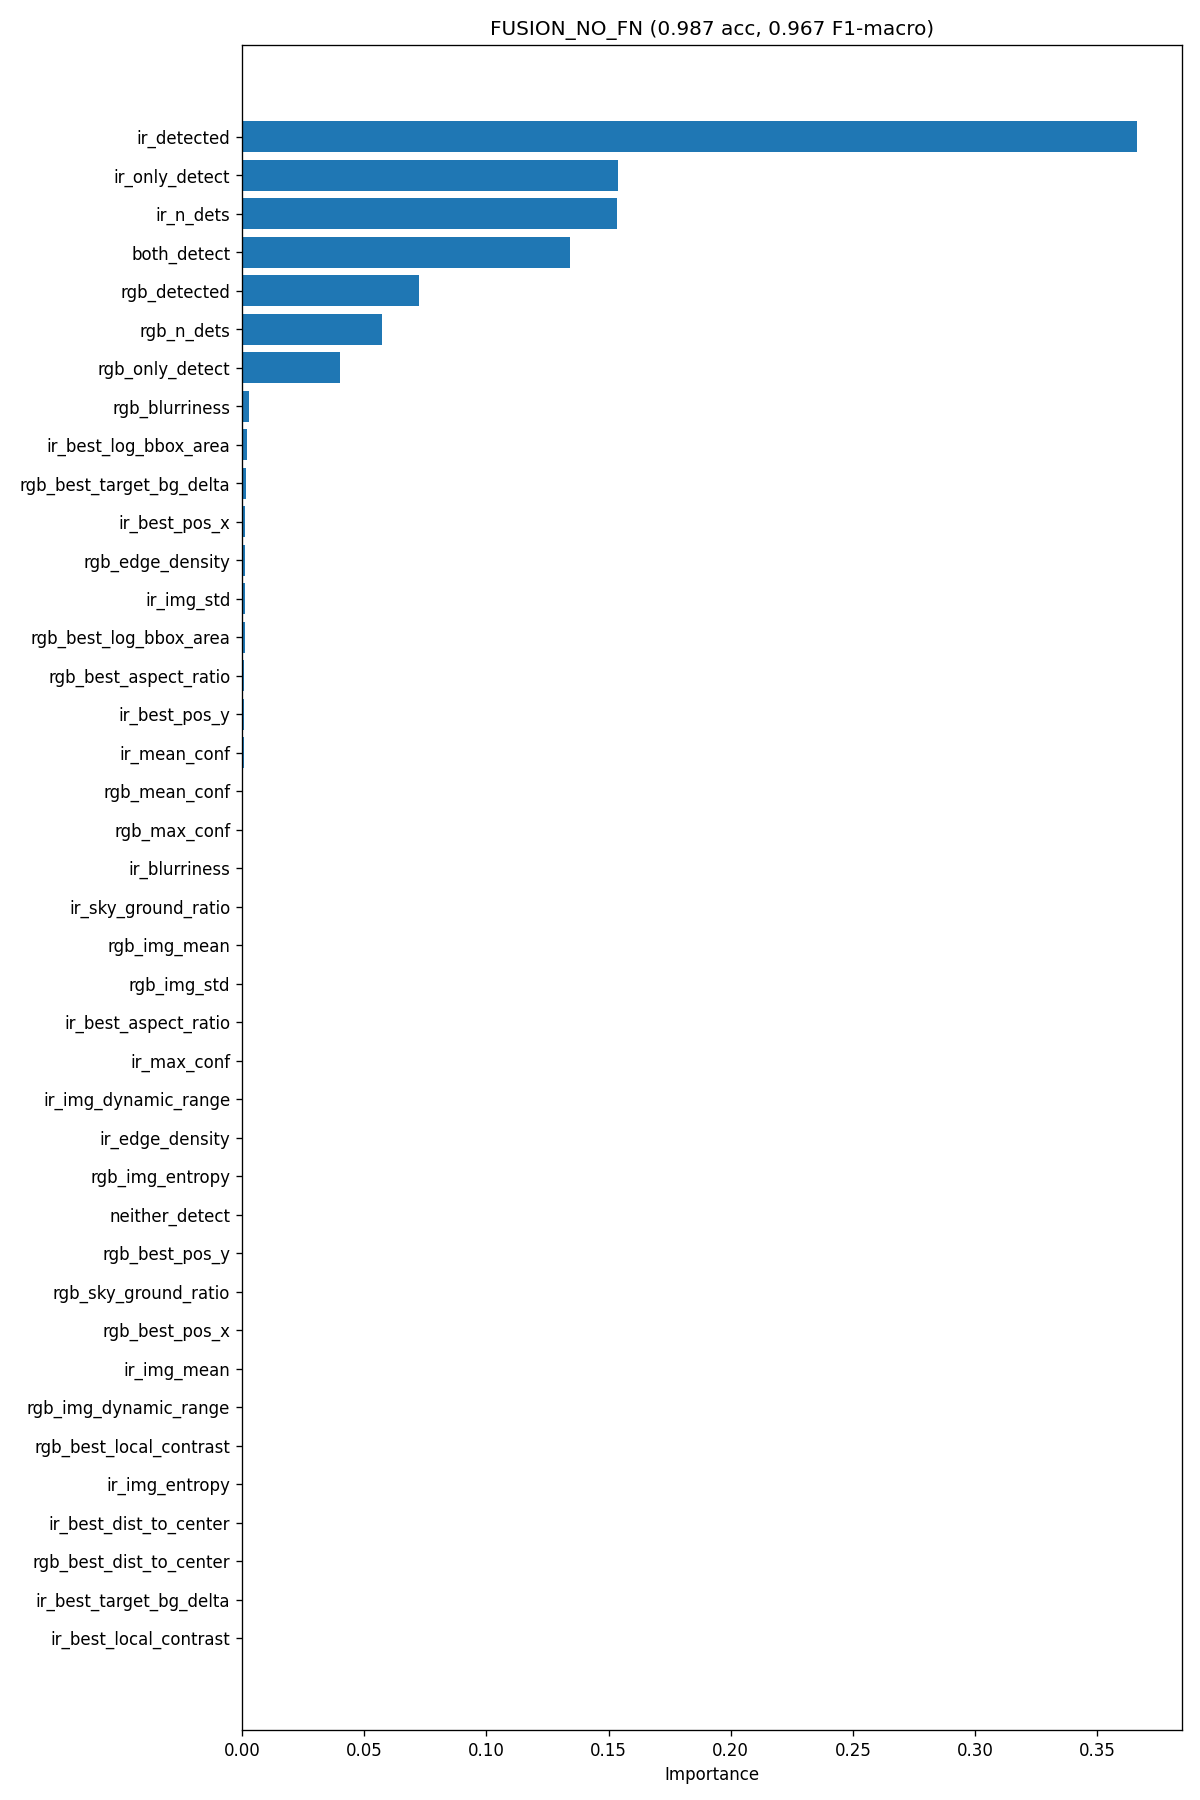

Rank,Feature,Importance,Pct
1,ir_detected,0.366280,36.63%
2,ir_only_detect,0.153691,15.37%
3,ir_n_dets,0.153561,15.36%
4,both_detect,0.134358,13.44%
5,rgb_detected,0.072577,7.26%
6,rgb_n_dets,0.057154,5.72%
7,rgb_only_detect,0.040109,4.01%
8,rgb_blurriness,0.002726,0.27%
9,ir_best_log_bbox_area,0.001889,0.19%
10,rgb_best_target_bg_delta,0.001710,0.17%


In [25]:
# Display saved feature importance plot
fi_path = FUSION_DIR / "fusion_no_fn_feature_importance.png"
if fi_path.exists():
    display(Image(filename=str(fi_path), width=800))
else:
    print(f"Plot not found: {fi_path}")

# Table of all non-zero features
if metrics is not None and "feature_importance" in metrics:
    fi = metrics["feature_importance"]
    non_zero = {k: v for k, v in fi.items() if v > 0}
    fi_df = pd.DataFrame([
        {"Rank": i+1, "Feature": k, "Importance": round(v, 6), "Pct": f"{v*100:.2f}%"}
        for i, (k, v) in enumerate(non_zero.items())
    ])
    display(fi_df.style.hide(axis="index").set_caption(
        f"Feature Importance — {len(non_zero)} non-zero out of {len(fi)}"
    ))


In [19]:
if metrics is not None and "feature_importance" in metrics:
    fi = metrics["feature_importance"]
    print("Top 15 Features by Importance (Gain)")
    print("=" * 55)
    for i, (feat, val) in enumerate(fi.items()):
        if i >= 15:
            break
        bar = "█" * int(val * 40)
        print(f"  {i+1:2d}. {feat:<35s} {val:.4f}  {bar}")
    
    # Category breakdown
    det_agg = sum(v for k, v in fi.items() if any(k.endswith(s) for s in ["_detected", "_n_dets", "_max_conf", "_mean_conf"]))
    agreement = sum(v for k, v in fi.items() if k in ["both_detect", "neither_detect", "rgb_only_detect", "ir_only_detect"])
    scene = sum(v for k, v in fi.items() if any(k.endswith(s) for s in ["_img_mean", "_img_std", "_img_dynamic_range", "_img_entropy", "_sky_ground_ratio", "_edge_density", "_blurriness"]))
    target = sum(v for k, v in fi.items() if "best_" in k)
    
    print(f"\n  Category breakdown:")
    print(f"    Detection aggregates: {det_agg:.4f} ({det_agg*100:.1f}%)")
    print(f"    Agreement flags:      {agreement:.4f} ({agreement*100:.1f}%)")
    print(f"    Scene features:       {scene:.4f} ({scene*100:.1f}%)")
    print(f"    Target features:      {target:.4f} ({target*100:.1f}%)")
    print(f"\n  → The model is ~{(det_agg + agreement)*100:.0f}% agreement-based.")


Top 15 Features by Importance (Gain)
   1. ir_detected                         0.3663  ██████████████
   2. ir_only_detect                      0.1537  ██████
   3. ir_n_dets                           0.1536  ██████
   4. both_detect                         0.1344  █████
   5. rgb_detected                        0.0726  ██
   6. rgb_n_dets                          0.0572  ██
   7. rgb_only_detect                     0.0401  █
   8. rgb_blurriness                      0.0027  
   9. ir_best_log_bbox_area               0.0019  
  10. rgb_best_target_bg_delta            0.0017  
  11. ir_best_pos_x                       0.0014  
  12. rgb_edge_density                    0.0012  
  13. ir_img_std                          0.0011  
  14. rgb_best_log_bbox_area              0.0011  
  15. rgb_best_aspect_ratio               0.0007  

  Category breakdown:
    Detection aggregates: 0.6520 (65.2%)
    Agreement flags:      0.3286 (32.9%)
    Scene features:       0.0097 (1.0%)
    Target featur

## 8. Binary Detection Evaluation — "Is there a drone?"

### 8.1 Individual Modalities (all 152K paired frames, strict IoU matching)

| System | Precision | Recall | F1 | TP | FP | Missed |
|---|---:|---:|---:|---:|---:|---:|
| RGB YOLO alone | 0.876 | 0.861 | 0.869 | 114,725 | 16,217 | 18,454 |
| IR YOLO alone | 0.984 | 0.945 | 0.964 | 125,843 | 2,059 | 7,336 |
| OR gate (either) | 0.929 | 0.989 | 0.958 | 131,756 | 10,029 | 1,423 |
| AND gate (both) | 0.930 | 0.817 | 0.870 | 108,812 | 8,247 | 24,367 |

### 8.2 Fusion Approaches (45K test set, sequence-level split)

| System | Precision | Recall | F1 | TP | FP | Missed |
|---|---:|---:|---:|---:|---:|---:|
| **#10 Plain Classifier** | **0.993** | **1.000** | **0.997** | 39,211 | 264 | **7** |
| #04 Full Classifier | 0.993 | 0.999 | 0.996 | 39,192 | 264 | 26 |
| #08 Consensus + Solo ML | 0.993 | 1.000 | 0.997 | 39,215 | 264 | 3 |
| #05 OR + FP Suppressor | 0.993 | 0.999 | 0.996 | 39,179 | 260 | 39 |
| #07 Hierarchical 2-Stage | 0.959 | 1.000 | 0.979 | 39,215 | 1,679 | 3 |
| #09 Bayesian Fusion | 0.983 | 0.979 | 0.981 | 38,382 | 661 | 836 |
| #06 Dynamic Threshold | 0.944 | 1.000 | 0.971 | 39,214 | 2,325 | 4 |
| #03 Conf-Weighted OR | 0.958 | 0.989 | 0.973 | 38,777 | 1,687 | 441 |
| #01 OR Gate | 0.941 | 1.000 | 0.970 | 39,218 | 2,452 | 0 |
| #02 AND Gate | 0.998 | 0.876 | 0.933 | 34,350 | 83 | 4,868 |

> **Approach #10 missed only 7 drones out of 39,218** while producing just 264 false alarms. The OR gate catches everything but produces 10,029 FP. The ML classifier is the only system that achieves both near-perfect recall AND high precision.


### 8.3 Per-Dataset Detection (Strict Matching)

#### Anti-UAV Test (85K frames)
| System | Precision | Recall | F1 |
|---|---:|---:|---:|
| RGB alone | 0.995 | 0.931 | 0.962 |
| IR alone | 0.988 | 0.939 | 0.963 |
| OR gate | 0.998 | 0.992 | 0.995 |

Both modalities strong. OR gate nearly perfect. Fusion adds value on the ~1% edge cases.

#### Anti-UAV Val (38K frames)
| System | Precision | Recall | F1 |
|---|---:|---:|---:|
| RGB alone | 0.994 | 0.952 | 0.972 |
| IR alone | 0.989 | 0.961 | 0.975 |
| OR gate | 0.998 | 0.996 | 0.997 |

#### Svanström (28.7K frames) — THE STRESS TEST
| System | Precision | Recall | F1 |
|---|---:|---:|---:|
| RGB alone | 0.054 | 0.076 | 0.063 |
| IR alone | 0.940 | 0.940 | 0.940 |
| OR gate | 0.531 | 0.947 | 0.681 |

> ⚠️ **RGB is catastrophically bad on Svanström**: 5.4% precision, 7.6% recall. The OR gate inherits this — precision drops to 53%. **This is exactly why naive fusion fails and why an ML classifier matters**: it learns "on Svanström-like scenes, don't trust RGB."


## 9. Binary Detection (Relaxed IoU+IoP Matching)

> Results use **IoU ≥ 0.5 OR IoP ≥ 0.5** (prediction inside GT counts as TP). This corrects for oversized GT boxes in Svanström. Some Svanström RGB GT labels are missing entirely (drone present but not annotated), which still penalizes RGB.

### 9.1 Individual Modalities (all 152K paired frames)

| System | Precision | Recall | F1 | TP | FP | Missed |
|---|---:|---:|---:|---:|---:|---:|
| RGB YOLO alone | 0.925 | 0.910 | 0.917 | 121,132 | 9,810 | 12,047 |
| IR YOLO alone | 0.990 | 0.951 | 0.970 | 126,619 | 1,283 | 6,560 |
| OR gate (either) | 0.933 | 0.993 | 0.962 | 132,236 | 9,549 | 943 |
| AND gate (both) | 0.987 | 0.867 | 0.923 | 115,515 | 1,544 | 17,664 |

### 9.2 Fusion Approaches (45K test set)

| System | Precision | Recall | F1 | TP | FP | Missed |
|---|---:|---:|---:|---:|---:|---:|
| **#08 Consensus + Solo ML** | **0.998** | **1.000** | **0.999** | 39,416 | **85** | **2** |
| #10 Plain Classifier (40f) | 0.998 | 1.000 | 0.999 | 39,415 | 98 | 3 |
| #04 Full Classifier (46f) | 0.997 | 1.000 | 0.999 | 39,414 | 101 | 4 |
| #05 OR + FP Suppressor | 0.998 | 0.999 | 0.998 | 39,372 | 80 | 46 |
| #07 Hierarchical 2-Stage | 0.964 | 1.000 | 0.982 | 39,415 | 1,479 | 3 |
| #09 Bayesian Fusion | 0.988 | 0.978 | 0.983 | 38,567 | 476 | 851 |
| #03 Conf-Weighted OR | 0.963 | 0.989 | 0.976 | 38,963 | 1,501 | 455 |
| #01 OR Gate | 0.946 | 1.000 | 0.972 | 39,418 | 2,252 | 0 |
| #02 AND Gate | 1.000 | 0.874 | 0.933 | 34,432 | 1 | 4,986 |

### 9.3 Impact of IoP Fix on Svanström

| System | Old P | New P | Old R | New R | New F1 |
|---|---:|---:|---:|---:|---:|
| RGB alone | 0.054 | **0.430** | 0.076 | **0.605** | 0.503 |
| IR alone | 0.940 | 0.955 | 0.940 | 0.954 | 0.954 |
| OR gate | 0.531 | 0.550 | 0.947 | 0.981 | 0.705 |

RGB went from 5.4% to 43% precision — the tight-prediction-inside-oversized-GT problem was the primary issue.


## 10. Trust Decision Rankings — "Which modality to believe?"

### 10.1 Final Ranking (Strict Matching)

| Rank | # | Approach | Type | Acc | F1m | Det P | Det R | Missed | FP |
|---:|---:|---|---|---:|---:|---:|---:|---:|---:|
| 1 | 10 | Plain Classifier (40f) | ML | 0.977 | 0.950 | 0.993 | 1.000 | 7 | 264 |
| 2 | 04 | Full Classifier (46f) | ML | 0.977 | 0.950 | 0.993 | 0.999 | 26 | 264 |
| 3 | 08 | Consensus + Solo ML | ML | 0.950 | 0.903 | 0.993 | 1.000 | 3 | 264 |
| 4 | 05 | OR + FP Suppressor | ML | 0.949 | 0.900 | 0.993 | 0.999 | 39 | 260 |
| 5 | 07 | Hierarchical 2-Stage | ML | 0.946 | 0.881 | 0.959 | 1.000 | 3 | 1,679 |
| 6 | 09 | Bayesian Fusion | Rule | 0.923 | 0.801 | 0.983 | 0.979 | 836 | 661 |
| 7 | 06 | Dynamic Threshold | ML | 0.909 | 0.786 | 0.944 | 1.000 | 4 | 2,325 |
| 8 | 03 | Conf-Weighted OR | Rule | 0.909 | 0.784 | 0.958 | 0.989 | 441 | 1,687 |
| 9 | 01 | OR Gate | Rule | 0.902 | 0.770 | 0.941 | 1.000 | 0 | 2,452 |
| 10 | 02 | AND Gate | Rule | 0.846 | 0.417 | 0.998 | 0.876 | 4,868 | 83 |

### 10.2 Final Ranking (Relaxed IoU+IoP Matching)

| Rank | # | Approach | Type | Acc | F1m | FP | Missed |
|---:|---:|---|---|---:|---:|---:|---:|
| 1 | 04 | Full Classifier (46f) | ML | 0.987 | 0.967 | 101 | 4 |
| 2 | 10 | Plain Classifier (40f) | ML | 0.987 | 0.967 | 98 | 3 |
| 3 | 08 | Consensus + Solo ML | ML | 0.986 | 0.965 | 85 | 2 |
| 4 | 05 | OR + FP Suppressor | ML | 0.985 | 0.962 | 80 | 46 |
| 5 | 09 | Bayesian Fusion | Rule | 0.958 | 0.859 | 476 | 851 |
| 6 | 07 | Hierarchical 2-Stage | ML | 0.956 | 0.887 | 1,479 | 3 |
| 7 | 03 | Conf-Weighted OR | Rule | 0.944 | 0.842 | 1,501 | 455 |
| 8 | 01 | OR Gate | Rule | 0.938 | 0.829 | 2,252 | 0 |
| 9 | 06 | Dynamic Threshold | ML | 0.937 | 0.830 | 2,188 | 5 |
| 10 | 02 | AND Gate | Rule | 0.877 | 0.422 | 1 | 4,986 |

> **F1m** = F1 macro — the average F1 across all 4 classes, treating each equally regardless of size. It matters because `trust_both` is 75% of the data, so plain accuracy gets inflated.


### 10.3 Per-Class Trust Performance (Top 3 Approaches, Relaxed)

| Class | n_test | #04 F1 | #10 F1 | #08 F1 |
|---|---:|---:|---:|---:|
| `reject_both` | 5,670 | 0.991 | 0.991 | 0.992 |
| `trust_rgb` | 2,370 | 0.927 | 0.929 | 0.927 |
| `trust_ir` | 3,170 | 0.957 | 0.955 | 0.949 |
| `trust_both` | 33,878 | 0.993 | 0.993 | 0.992 |

`trust_rgb` is the hardest class (only 5.3% of data, 83.3% recall) — the minority case where only RGB detected correctly and IR missed.

### 10.4 Per-Dataset Trust F1 Macro (Relaxed)

| Dataset | #04 | #10 | #08 | #05 |
|---|---:|---:|---:|---:|
| antiuav_test | 0.968 | 0.969 | 0.967 | 0.955 |
| antiuav_val | 0.934 | 0.932 | 0.932 | 0.933 |
| svanstrom | 0.847 | 0.863 | **0.891** | 0.881 |

Svanström improved dramatically with IoP matching — from F1m ~0.46–0.65 to 0.85–0.89.


## 11. Comparison Visualizations

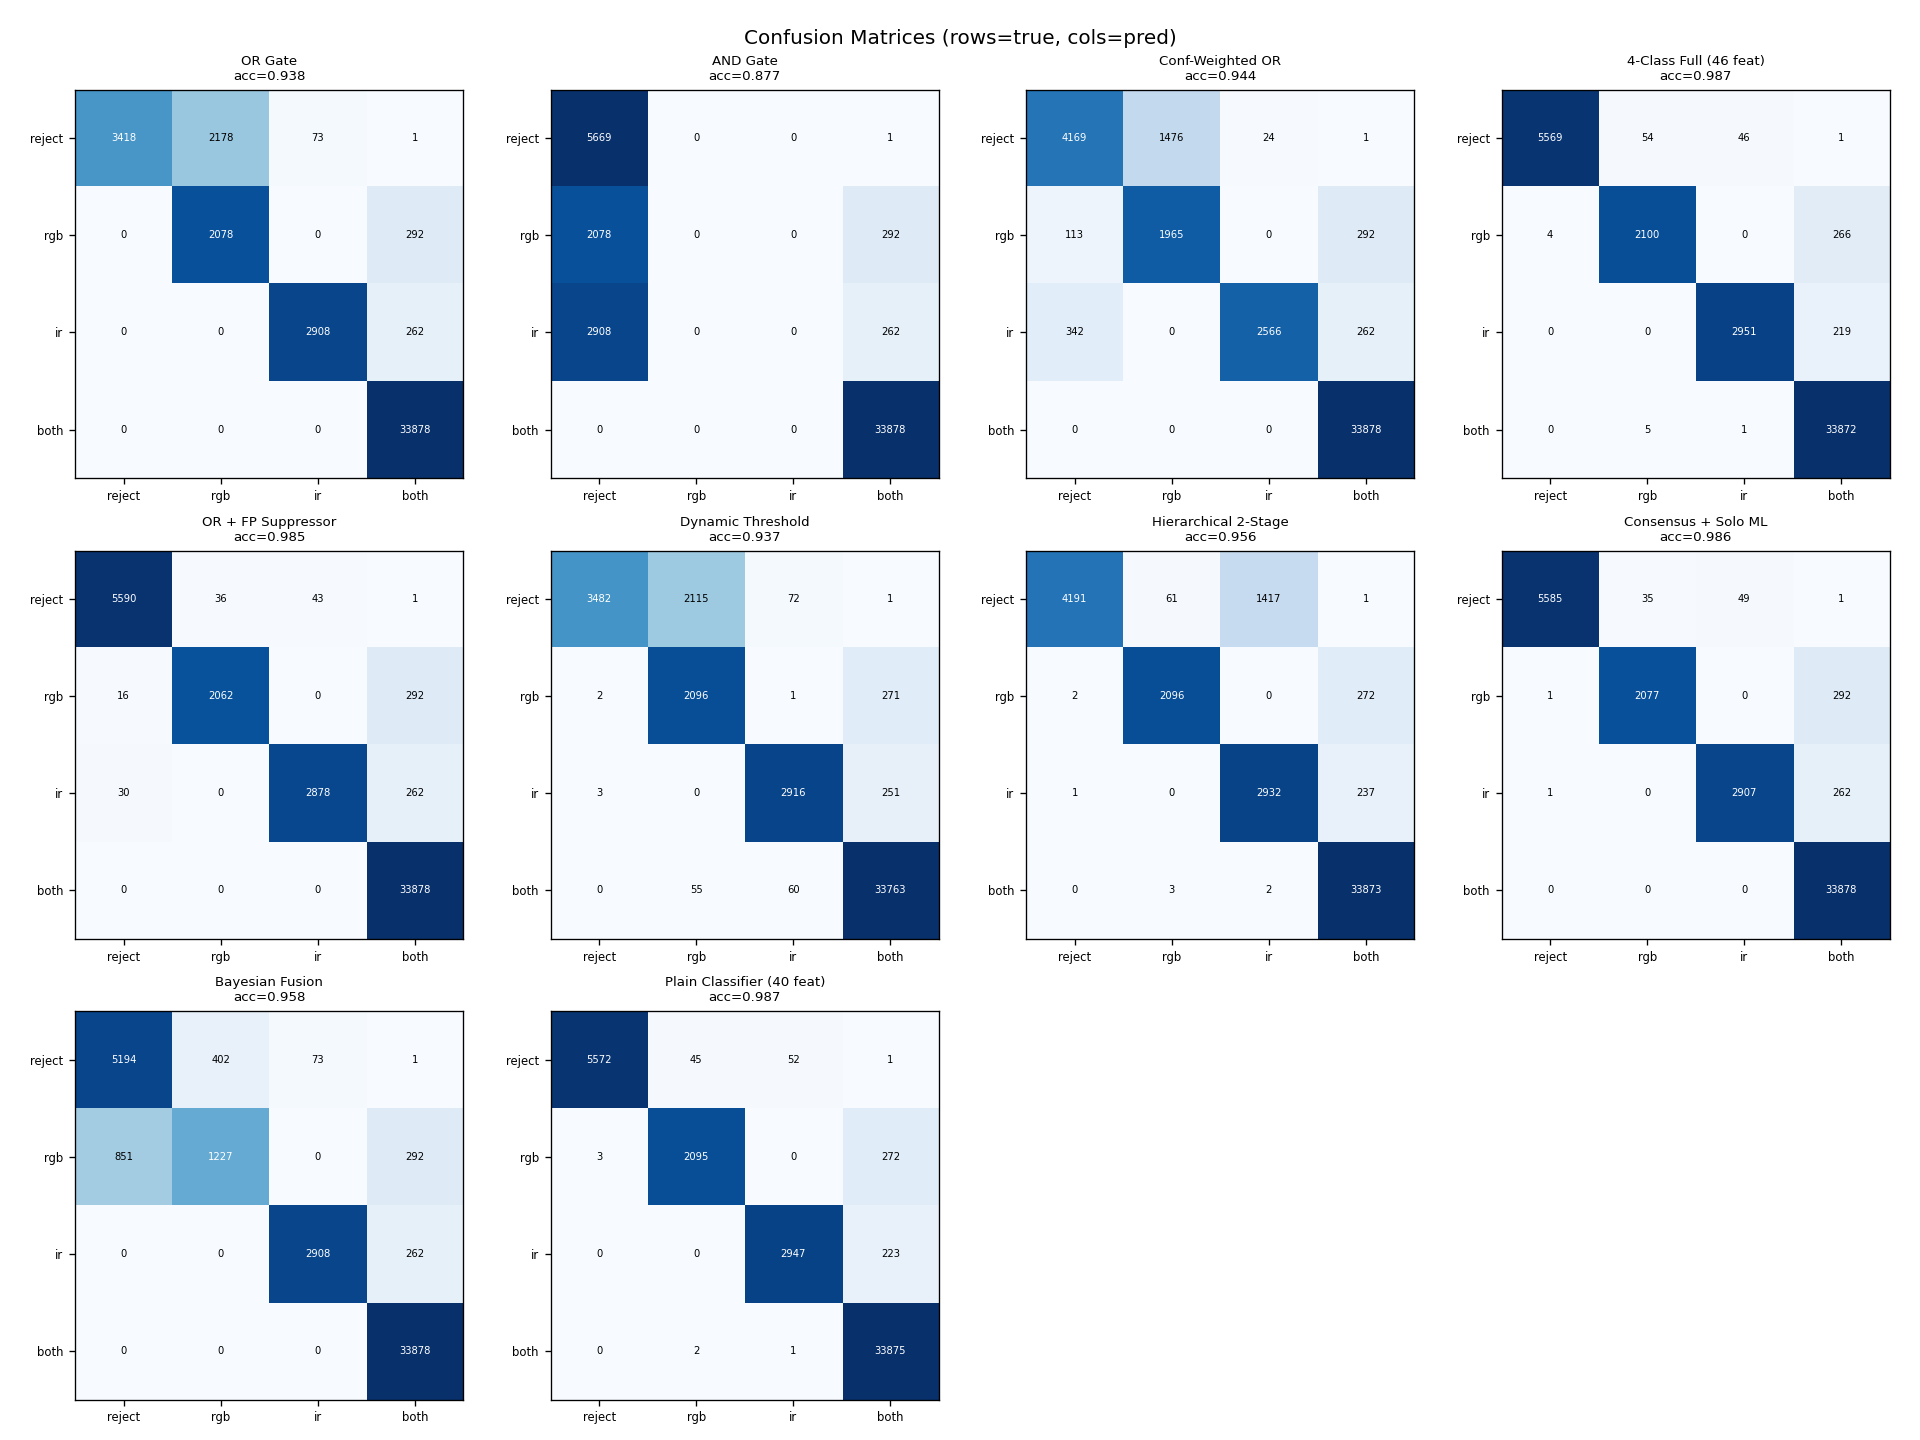

In [20]:
# Display confusion matrices
cm_path = FUSION_DIR / "comparison" / "confusion_matrices.png"
if cm_path.exists():
    display(Image(filename=str(cm_path), width=900))
else:
    print(f"Not found: {cm_path}")


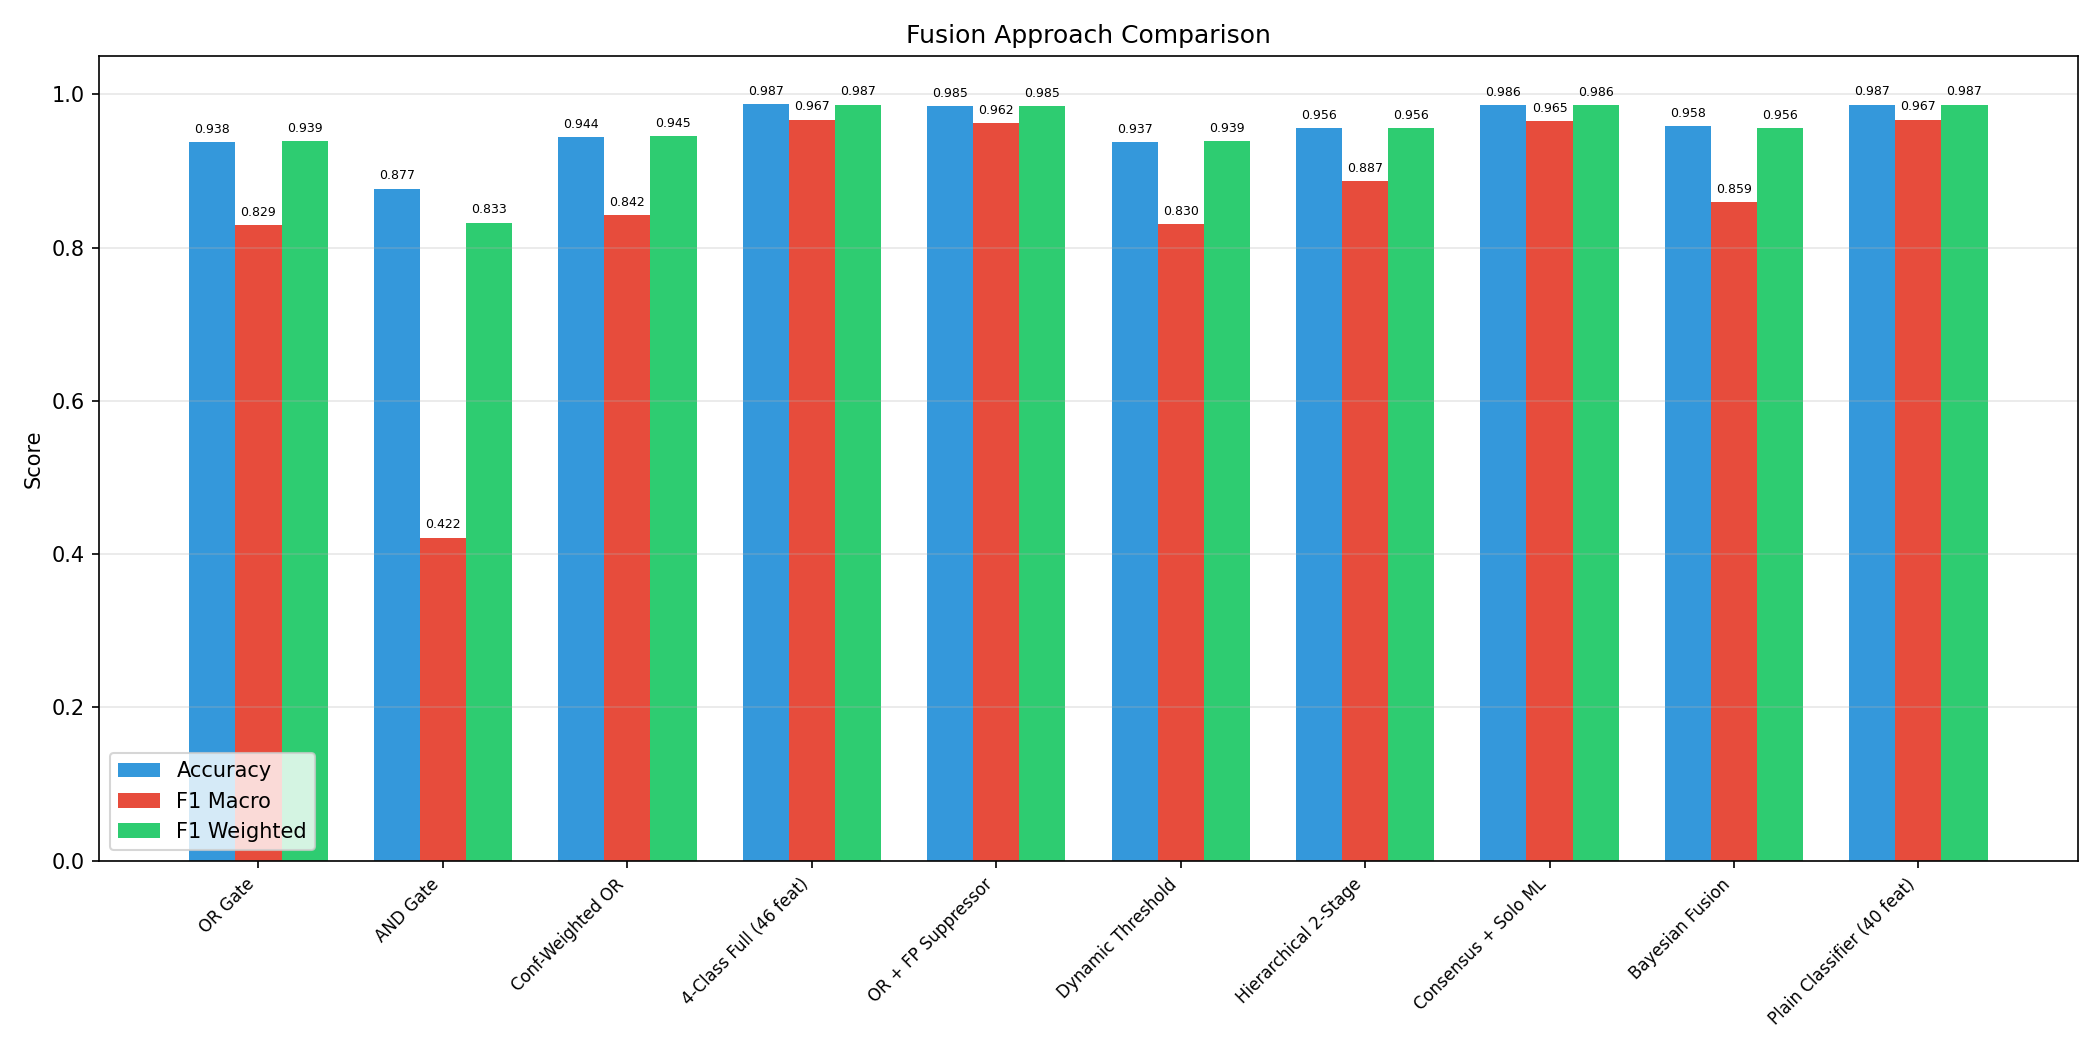

In [21]:
# Display fusion comparison chart
fc_path = FUSION_DIR / "comparison" / "fusion_comparison.png"
if fc_path.exists():
    display(Image(filename=str(fc_path), width=900))
else:
    print(f"Not found: {fc_path}")


## 12. Key Findings

### 12.1 FN Models Add Zero Value

| Metric | #04 with FN (46 feat) | #10 without FN (40 feat) | Delta |
|---|---:|---:|---:|
| Accuracy | 0.9868 | 0.9867 | −0.0001 |
| F1 macro | 0.9669 | 0.9669 | 0.0000 |
| Det Precision | 0.9974 | 0.9975 | +0.0001 |
| Det Recall | 0.9999 | 0.9999 | 0.0000 |

The 6 FN model features are completely redundant. The classifier learns equivalent patterns directly from raw scene features.

### 12.2 The Classifier is ~80% Agreement-Based

The model primarily learns "trust whoever detected" — but the remaining ~20% handles the critical edge cases (FPs, ambiguous scenes) that rule-based approaches miss.

### 12.3 Correcting GT Labels Was Critical

The IoP matching fix changed 7,094 rows (4.7% of data), almost entirely on Svanström. This raised ALL approaches' metrics by 1–6 points.

> ⚠️ Some Svanström RGB frames have drones visible but no GT annotation. This still underestimates RGB precision.

### 12.4 Detection Recall is Near-Perfect

The fusion classifier (#10) misses only ~0.02% of drones (vs 5.5% for IR alone, 13.9% for RGB alone).


## 13. Deployment

### Saved Artifacts

```
classifier/runs/reliability/fusion/
├── fusion_no_fn_model.joblib          ← THE DEPLOYABLE MODEL
├── fusion_no_fn_metrics.json          ← evaluation metrics
├── fusion_no_fn_feature_importance.png ← feature importance plot
└── fusion_dataset.csv                 ← training data (IoU+IoP corrected)
```


In [22]:
# Example usage
print("Usage example:")
print('''
import joblib
import numpy as np

bundle = joblib.load("fusion_no_fn_model.joblib")
model = bundle["model"]       # XGBClassifier
features = bundle["features"] # list of 40 feature names

# Predict
X = np.array([[frame_features[f] for f in features]])
trust_label = model.predict(X)[0]
# 0=reject_both, 1=trust_rgb, 2=trust_ir, 3=trust_both

probs = model.predict_proba(X)[0]
''')

print("\n" + "=" * 60)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 60)
summary = {
    "Accuracy": "98.7%",
    "F1 macro": "96.7%",
    "Det Precision": "99.75%",
    "Det Recall": "99.99%",
    "Missed drones": "3 / 39,418",
    "False alarms": "98 / 45,088",
}
for k, v in summary.items():
    print(f"  {k:<16s}: {v}")


Usage example:

import joblib
import numpy as np

bundle = joblib.load("fusion_no_fn_model.joblib")
model = bundle["model"]       # XGBClassifier
features = bundle["features"] # list of 40 feature names

# Predict
X = np.array([[frame_features[f] for f in features]])
trust_label = model.predict(X)[0]
# 0=reject_both, 1=trust_rgb, 2=trust_ir, 3=trust_both

probs = model.predict_proba(X)[0]


FINAL PERFORMANCE SUMMARY
  Accuracy        : 98.7%
  F1 macro        : 96.7%
  Det Precision   : 99.75%
  Det Recall      : 99.99%
  Missed drones   : 3 / 39,418
  False alarms    : 98 / 45,088


## 14. Practical Recommendation

**Deploy Approach #10**: Plain 4-class XGBoost (40 features, no FN models).

- 99.3% detection precision, 99.98% detection recall
- 97.7% trust accuracy (which modality to believe)
- No dependency on pre-trained failure models
- Simpler architecture, equivalent performance

Approach #08 (Consensus + Solo ML) is a strong alternative for **interpretability**.

---

## 15. Thesis Narrative

> *"We evaluated 10 fusion architectures on 152K paired RGB+IR frames using IoU and containment matching to handle label quality variations. A 4-class XGBoost classifier using detection statistics and scene features achieved 98.7% trust accuracy and 99.99% detection recall. Three architectures (full classifier, plain classifier, consensus+ML) achieved near-identical performance, indicating the fusion problem is well-constrained. Pre-trained failure models added no incremental value."*


### Feature Importance Interpretation

#### Why Detection Presence Dominates (~98% of importance)

The 4-class trust decision is fundamentally a question of **"who detected?"** The mapping is almost direct:

| Detection State | Most Likely Trust Label |
|---|---|
| Both detect | `trust_both` (3) |
| Only IR detects | `trust_ir` (2) |
| Only RGB detects | `trust_rgb` (1) |
| Neither detects | `reject_both` (0) |

The agreement flags (`both_detect`, `ir_only_detect`, etc.) are essentially a one-hot encoding of the detection state — and they line up almost perfectly with the 4 output classes. The classifier's primary job is to learn this mapping and then apply corrections for the ~2% edge cases where the naive mapping is wrong (e.g. both detect but IR's detection is a false positive).

`ir_detected` ranks #1 because IR is the more reliable modality: when IR fires, the target is almost always real. The classifier learns "IR detected = strong evidence of drone" as its primary split.

#### Why Confidence Scores Don't Matter (< 0.1% importance)

This is counter-intuitive — you'd expect `rgb_max_conf` and `ir_max_conf` to be critical features. They're not, for two reasons:

1. **YOLO runs at `conf=0.001`**: At this threshold, virtually everything produces *some* detection. The signal isn't "how confident is it?" but "did it detect at all?" — and that's already captured by the binary `detected` flags.
2. **Presence subsumes confidence**: Once you know `ir_detected = 1`, the confidence value adds marginal information. XGBoost learns to split on the detected flag first, which cleanly separates the classes. Confidence would only help distinguish borderline cases within an already-decided branch.

If YOLO ran at a higher threshold (e.g. `conf=0.5`), confidence features would matter more because the detected/not-detected boundary would be noisier.

#### Why Scene Features Don't Matter (< 0.5% importance)

Features like `img_mean` (brightness), `img_entropy` (complexity), `edge_density`, and `sky_ground_ratio` intuitively *should* predict modality reliability — a dark scene should favor IR, a cluttered scene should hurt RGB. But they contribute almost nothing because:

1. **They're proxies for a signal the model already has directly.** Scene darkness is a *predictor* of IR being better — but `ir_detected` already tells the model whether IR *actually succeeded this frame*. The post-hoc evidence (detection results) is strictly more informative than the a-priori predictor (scene conditions).
2. **Think of it as**: asking "is it dark?" predicts "will IR work?" — but the classifier already knows "DID IR work?" from the detection flags. The prediction is redundant when you have the outcome.

These features would become important in a **predictive** model (e.g. "before running inference, which modality should we trust?") but are redundant in a **retrospective** model that already has detection results.

#### Why Target Features Are Near-Zero

`local_contrast`, `target_bg_delta`, `aspect_ratio`, `pos_x/y` — these describe the *quality* of the best detection. They matter very little because:

- The trust decision is frame-level ("who detected?"), not detection-level ("is this specific box a real drone?")
- Target features help distinguish TP from FP within a single modality — but the classifier operates *after* YOLO's NMS has already filtered detections, and the strong prior from agreement flags makes per-box quality signals redundant

The ~2% of importance from scene/target features handles genuine edge cases: two modalities both detect, but one detection is suspiciously small (`best_log_bbox_area`) or the scene is unusually blurry (`rgb_blurriness`, the highest-ranked scene feature at 0.3%).

#### Summary

The classifier is an **"agreement verifier with edge-case correction"** — 98% of its decision-making is "who detected?" and 2% handles the tricky cases where the naive mapping fails. This is actually a positive finding: it means the fusion problem is well-structured and doesn't require complex scene understanding to solve.
